In [1]:
pip install scikit-survival

In [2]:
pip install lifelines

In [3]:
# Imports
import pandas as pd
import gzip
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
import numpy as np
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from scipy.stats import ttest_ind

# For colab usage
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Data location (colab)
df_survival = "/content/drive/MyDrive/AI_Healthcare_Internship/survival_BRCA_survival.txt"
df_gene_expression = "/content/drive/MyDrive/AI_Healthcare_Internship/TCGA.BRCA.sampleMap_HiSeqV2.gz"

# For reproduction in local environments
# Default path for reproducability (Download datasets from links in README)
"""df_survival = "./survival_BRCA_survival.txt"
df_gene_expression = "./TCGA.BRCA.sampleMap_HiSeqV2.gz"""

survivaldf = pd.read_csv(df_survival, sep="\t", engine="python")
survivaldf.head()

,sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,0,4047.0,0.0,4047.0,1.0,1808.0,1,1808.0,NaN
1,TCGA-3C-AALI-01,TCGA-3C-AALI,0,4005.0,0.0,4005.0,0.0,4005.0,0,4005.0,NaN
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,0,1474.0,0.0,1474.0,0.0,1474.0,0,1474.0,NaN
3,TCGA-3C-AALK-01,TCGA-3C-AALK,0,1448.0,0.0,1448.0,NaN,NaN,0,1448.0,NaN
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,0,348.0,0.0,348.0,0.0,348.0,0,348.0,NaN


In [5]:
# Take the columns we need
survivaldf = survivaldf[["sample", "OS", "OS.time"]]
survivaldf.head()

,sample,OS,OS.time
0,TCGA-3C-AAAU-01,0,4047.0
1,TCGA-3C-AALI-01,0,4005.0
2,TCGA-3C-AALJ-01,0,1474.0
3,TCGA-3C-AALK-01,0,1448.0
4,TCGA-4H-AAAK-01,0,348.0


In [6]:
# Check and remove duplicates
survivaldf.drop_duplicates(inplace=True)

In [7]:
print(survivaldf.isna().sum())

sample     0
OS         0
OS.time    1
dtype: int64


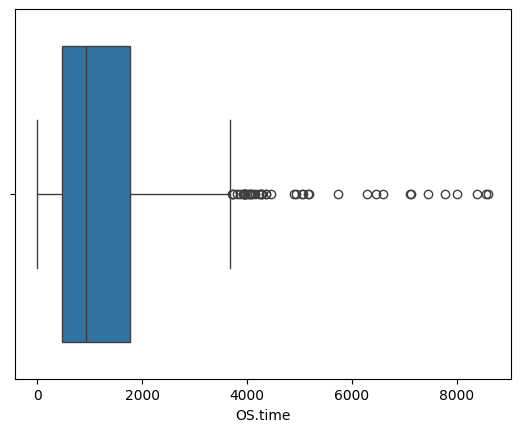

In [8]:
# Looking for outliers / extreme values using box plots
timeCol = survivaldf["OS.time"]
sns.boxplot(x=timeCol)
plt.show()

In [9]:
survivaldf = survivaldf.dropna()
survivaldf.head()

,sample,OS,OS.time
0,TCGA-3C-AAAU-01,0,4047.0
1,TCGA-3C-AALI-01,0,4005.0
2,TCGA-3C-AALJ-01,0,1474.0
3,TCGA-3C-AALK-01,0,1448.0
4,TCGA-4H-AAAK-01,0,348.0


In [10]:
# Ensure value was dropped
print(survivaldf.isna().sum())

sample     0
OS         0
OS.time    0
dtype: int64


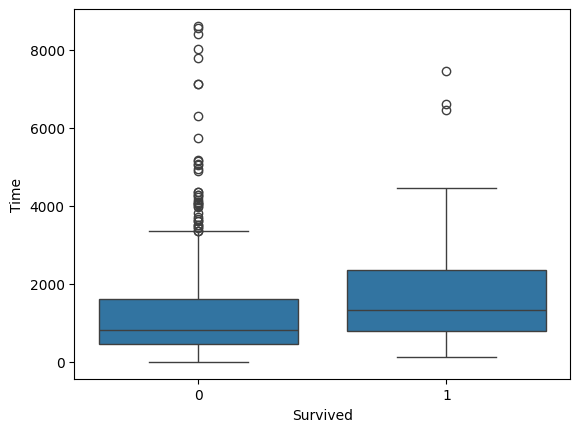

In [11]:
# Creating box plots to analyse survival event vs time
ax = sns.boxplot(x="OS", y="OS.time", data=survivaldf)
ax.set_xlabel("Survived")
ax.set_ylabel("Time")
plt.show()

In [12]:
# Ensure that value has been removed
print(survivaldf.isna().sum())

sample     0
OS         0
OS.time    0
dtype: int64


In [13]:
print(survivaldf.shape)

(1235, 3)


In [14]:
output_gene_expression_df = "/content/drive/MyDrive/AI_Healthcare_Internship/gene_expression.txt"

with gzip.open(df_gene_expression, 'rb') as f_in:
  with open(output_gene_expression_df, 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)

gene_expression_df = pd.read_csv(output_gene_expression_df, sep="\t", engine='python')
gene_expression_df.head()

,sample,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AC-A5XU-01,TCGA-PE-A5DE-01,...,TCGA-A7-A13E-11,TCGA-C8-A8HP-01,TCGA-E9-A5FL-01,TCGA-AC-A2FB-11,TCGA-E2-A15F-01,TCGA-A2-A3XT-01,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-3C-AALJ-01,TCGA-B6-A0X1-01
0,ARHGEF10L,9.5074,7.4346,9.3216,9.0198,9.6417,9.7665,10.0931,9.1524,9.9398,...,9.6265,10.1826,9.9199,9.9090,10.0334,11.5144,10.5745,9.4048,10.9468,10.3164
1,HIF3A,1.5787,3.6607,2.7224,1.3414,0.5819,0.2738,3.6090,0.4738,2.9378,...,8.1546,2.2159,3.8645,8.1872,0.8836,1.3169,4.0696,7.2537,0.9310,2.4191
2,RNF17,0.0000,0.6245,0.5526,0.0000,0.0000,0.8765,0.0000,0.0000,0.0000,...,0.0000,0.0000,3.7305,0.0000,0.0000,1.1329,0.4258,0.0000,0.0000,0.0000
3,RNF10,11.3676,11.9181,11.9665,13.1881,12.0036,11.8118,11.3820,11.5004,12.2055,...,11.9869,12.2653,12.4815,11.8263,12.0135,11.5818,11.8663,11.5460,12.2616,12.1570
4,RNF11,11.1292,13.5273,11.4105,11.0911,11.2545,10.8554,10.7663,10.4358,11.2210,...,11.9344,11.4117,10.4902,11.5754,10.8370,10.2736,10.7644,11.8774,10.7842,11.2420


In [15]:
# Dropping duplicates
gene_expression_df.drop_duplicates(inplace=True)

In [16]:
# Transpose the data
gene_expression_data = gene_expression_df.transpose()
gene_expression_data.columns = gene_expression_data.iloc[0]
gene_expression_data = gene_expression_data.drop(gene_expression_data.index[0])
gene_expression_data["sample"] = gene_expression_data.index

In [17]:
gene_expression_data.columns.name = None
gene_expression_data.index = range(len(gene_expression_data))
gene_expression_data.head()

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,sample
0,9.5074,1.5787,0.0,11.3676,11.1292,9.9722,11.5966,3.2396,0.0,3.5764,...,0.0,5.3307,0.5819,9.1928,13.8808,7.383,11.4289,7.8456,10.7384,TCGA-AR-A5QQ-01
1,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0,6.0854,...,0.0,3.1017,3.7793,9.834,10.7066,7.2467,9.1673,0.0,10.1225,TCGA-D8-A1JA-01
2,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0,5.8329,...,2.7224,4.2976,0.0,9.2304,12.9973,8.3374,11.34,8.3765,9.9367,TCGA-BH-A0BQ-01
3,9.0198,1.3414,0.0,13.1881,11.0911,10.4244,12.6427,2.7553,0.0,4.6308,...,2.9823,4.3067,0.0,8.7816,12.3298,7.7036,11.3025,7.0585,9.3784,TCGA-BH-A0BT-01
4,9.6417,0.5819,0.0,12.0036,11.2545,10.148,12.6622,4.2765,1.8007,4.4505,...,0.5819,3.5764,0.0,9.3024,11.3338,7.7186,10.6898,7.0992,11.174,TCGA-A8-A06X-01


In [18]:
gene_expression_data = gene_expression_data.apply(pd.to_numeric, errors='ignore')
gene_expression_data.head()

/tmp/ipykernel_45683/3029512732.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gene_expression_data = gene_expression_data.apply(pd.to_numeric, errors='ignore')


,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,sample
0,9.5074,1.5787,0.0000,11.3676,11.1292,9.9722,11.5966,3.2396,0.0000,3.5764,...,0.0000,5.3307,0.5819,9.1928,13.8808,7.3830,11.4289,7.8456,10.7384,TCGA-AR-A5QQ-01
1,7.4346,3.6607,0.6245,11.9181,13.5273,10.8702,12.3048,2.5547,0.0000,6.0854,...,0.0000,3.1017,3.7793,9.8340,10.7066,7.2467,9.1673,0.0000,10.1225,TCGA-D8-A1JA-01
2,9.3216,2.7224,0.5526,11.9665,11.4105,10.4406,12.8186,4.7115,0.0000,5.8329,...,2.7224,4.2976,0.0000,9.2304,12.9973,8.3374,11.3400,8.3765,9.9367,TCGA-BH-A0BQ-01
3,9.0198,1.3414,0.0000,13.1881,11.0911,10.4244,12.6427,2.7553,0.0000,4.6308,...,2.9823,4.3067,0.0000,8.7816,12.3298,7.7036,11.3025,7.0585,9.3784,TCGA-BH-A0BT-01
4,9.6417,0.5819,0.0000,12.0036,11.2545,10.1480,12.6622,4.2765,1.8007,4.4505,...,0.5819,3.5764,0.0000,9.3024,11.3338,7.7186,10.6898,7.0992,11.1740,TCGA-A8-A06X-01


In [19]:
expr = gene_expression_data.drop(columns="sample")

expr_filter = (expr > 1).sum(axis=0) > 0.2 * expr.shape[0]
expr_filtered = expr.loc[:, expr_filter]

gene_expression_data = pd.concat(
    [gene_expression_data["sample"], expr_filtered],
    axis=1
)

In [20]:
gene_expression_data.head()

,sample,ARHGEF10L,HIF3A,RNF10,RNF11,RNF13,GTF2IP1,REM1,RTN4RL2,C16orf13,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-AR-A5QQ-01,9.5074,1.5787,11.3676,11.1292,9.9722,11.5966,3.2396,3.5764,9.7940,...,0.5819,0.0000,5.3307,0.5819,9.1928,13.8808,7.3830,11.4289,7.8456,10.7384
1,TCGA-D8-A1JA-01,7.4346,3.6607,11.9181,13.5273,10.8702,12.3048,2.5547,6.0854,7.6658,...,1.0589,0.0000,3.1017,3.7793,9.8340,10.7066,7.2467,9.1673,0.0000,10.1225
2,TCGA-BH-A0BQ-01,9.3216,2.7224,11.9665,11.4105,10.4406,12.8186,4.7115,5.8329,10.0717,...,0.0000,2.7224,4.2976,0.0000,9.2304,12.9973,8.3374,11.3400,8.3765,9.9367
3,TCGA-BH-A0BT-01,9.0198,1.3414,13.1881,11.0911,10.4244,12.6427,2.7553,4.6308,10.7406,...,0.0000,2.9823,4.3067,0.0000,8.7816,12.3298,7.7036,11.3025,7.0585,9.3784
4,TCGA-A8-A06X-01,9.6417,0.5819,12.0036,11.2545,10.1480,12.6622,4.2765,4.4505,9.6876,...,1.3163,0.5819,3.5764,0.0000,9.3024,11.3338,7.7186,10.6898,7.0992,11.1740


In [21]:
survivaldf.head()

,sample,OS,OS.time
0,TCGA-3C-AAAU-01,0,4047.0
1,TCGA-3C-AALI-01,0,4005.0
2,TCGA-3C-AALJ-01,0,1474.0
3,TCGA-3C-AALK-01,0,1448.0
4,TCGA-4H-AAAK-01,0,348.0


In [22]:
# Checking data dimensionality
print(gene_expression_data.shape)

(1218, 17704)


In [23]:
# Checking missing values, shows there is no need for imputing.
print(gene_expression_data.isna().sum())

sample       0
ARHGEF10L    0
HIF3A        0
RNF10        0
RNF11        0
            ..
PTRF         0
BCL6B        0
GSTK1        0
SELP         0
SELS         0
Length: 17704, dtype: int64


In [24]:
survivaldf = survivaldf.set_index("sample")
gene_df = gene_expression_data.set_index("sample")

common_samples = survivaldf.index.intersection(gene_df.index)

survivaldf = survivaldf.loc[common_samples]
gene_df = gene_df.loc[common_samples]

In [25]:
from lifelines.statistics import logrank_test
import numpy as np

logrank_results = []

for gene in gene_df.columns:
    expr = gene_df[gene]

    high = expr > expr.median()

    res = logrank_test(
        survivaldf.loc[high, "OS.time"],
        survivaldf.loc[~high, "OS.time"],
        event_observed_A=survivaldf.loc[high, "OS"],
        event_observed_B=survivaldf.loc[~high, "OS"]
    )

    logrank_results.append({
        "gene": gene,
        "p": res.p_value
    })

logrank_df = pd.DataFrame(logrank_results)

screened_genes = logrank_df[logrank_df["p"] < 0.01]["gene"]
print(len(screened_genes))

1844


In [26]:
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError

results = []
cph = CoxPHFitter()

for gene in screened_genes:  # the 1844 genes
    df_tmp = survivaldf[["OS.time", "OS"]].copy()
    df_tmp["expr"] = gene_df[gene]

    try:
        cph.fit(
            df_tmp,
            duration_col="OS.time",
            event_col="OS",
            show_progress=False
        )

        results.append({
            "gene": gene,
            "beta": cph.params_["expr"],
            "p": cph.summary.loc["expr", "p"]
        })

    except ConvergenceError:
        continue

cox_df = pd.DataFrame(results)
cox_df.head()

,gene,beta,p
0,GTF2IP1,-0.268611,0.078916
1,ATRX,0.310050,0.004638
2,ASS1,0.095310,0.030295
3,CAMK4,-0.233308,0.000050
4,ZNF704,0.174134,0.003006


In [27]:
from statsmodels.stats.multitest import multipletests

cox_df["q"] = multipletests(cox_df["p"], method="fdr_bh")[1]

In [28]:
final_genes = cox_df[
    (cox_df["q"] < 0.05)
]

final_genes = final_genes[final_genes["beta"].abs() > 0.2]

gene_df = gene_df[final_genes["gene"]]
gene_df.head()

,ATRX,CAMK4,ITGA1,FAM116B,HIBCH,MUS81,IGF2R,ST13,MGC57346,SIPA1,...,PSMF1,DYX1C1,ICT1,STRN4,STON1,PSPN,RGS14,MINA,ACAP2,BCL6B
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-3C-AAAU-01,11.7001,4.4151,9.4088,8.0574,8.9709,8.9520,10.8705,11.8530,8.6396,9.0677,...,11.6754,6.7154,8.8030,11.0397,6.0672,2.3606,10.1098,9.7607,10.4170,7.8250
TCGA-3C-AALI-01,9.7384,3.6963,9.2917,8.0275,7.8348,9.3724,11.3837,11.6149,6.3377,9.9704,...,12.3172,5.7633,9.1404,12.0358,7.7751,1.6668,9.4349,9.2306,10.1252,8.1093
TCGA-3C-AALJ-01,9.9302,4.5084,9.7662,7.9306,7.6794,9.3243,10.7359,11.3211,6.5867,10.1670,...,11.3328,6.7787,9.5505,11.8416,7.8134,2.2099,9.1209,7.7289,9.4771,8.7597
TCGA-3C-AALK-01,10.5079,4.0275,8.9515,8.6684,8.5154,9.6136,11.5442,12.2208,5.9403,10.2068,...,11.3494,7.0401,9.9553,11.3088,7.7053,1.1643,8.3750,9.4828,9.5377,7.9614
TCGA-4H-AAAK-01,10.5833,4.7297,8.8572,8.4597,8.6986,9.3000,11.5167,12.1296,7.6381,9.7086,...,11.2261,7.0169,8.9551,11.3986,7.3363,0.8884,8.1880,10.2286,10.0101,7.6902


In [29]:
# Modify n_components until reaching explained variance threshold
# I will take 85% as the threshold, as having a threshold that is very high (such as 95%) will still lead to large dimensionality (as shown in the table of cumulative explained variance below)
principal_components = PCA(n_components=200)
numerical_cols = gene_df.select_dtypes(include="number").columns

pca_df = principal_components.fit(gene_df.select_dtypes(include="number"))

print(pca_df.explained_variance_ratio_.cumsum() * 100)


[24.16218536 31.62662111 37.67257508 41.54087029 44.45310751 46.41834944
 48.14221518 49.6144971  50.77367054 51.91291105 52.97079233 53.88289194
 54.73802659 55.55447882 56.33657317 57.0749338  57.75406739 58.41926366
 59.06334596 59.67890934 60.2865484  60.88568317 61.42506504 61.96106952
 62.48796358 63.00029671 63.50431118 63.98319535 64.44024328 64.8842947
 65.31922819 65.73860459 66.14436907 66.53803743 66.92546731 67.3092467
 67.68695392 68.05686294 68.41907866 68.77348293 69.1178948  69.45030568
 69.7724901  70.08948176 70.40019982 70.70528935 71.00640059 71.3014278
 71.59399774 71.87947616 72.1594134  72.43528731 72.70580169 72.96943971
 73.23090368 73.48277727 73.73090307 73.97510478 74.21681441 74.45679574
 74.69266883 74.92461871 75.15277403 75.3789962  75.60162767 75.82157612
 76.03549844 76.2456892  76.45180716 76.65748614 76.86097951 77.06091196
 77.25662897 77.44972611 77.6405784  77.8305654  78.01771188 78.20387308
 78.38633044 78.56824788 78.74762513 78.92348354 79.09

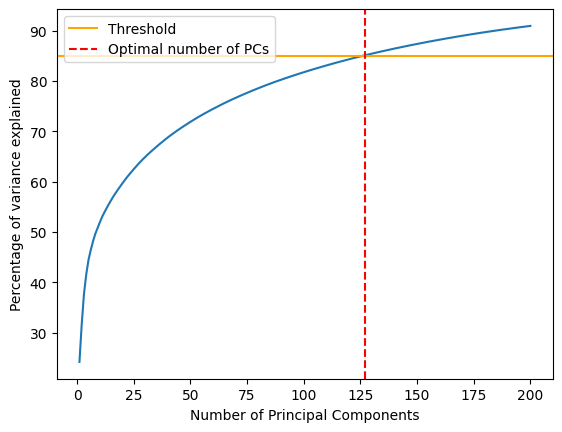

127


In [30]:
# I will plot the explained variance ratio values on a line graph
explained_ratios = pca_df.explained_variance_ratio_.cumsum() * 100

# Must round up to a whole number as you cannot have .x number of PCAs
min_pca_for_threshold = (explained_ratios >= 85).argmax() + 1

ax = sns.lineplot(x=range(1,201), y=explained_ratios)

ax.axhline(y=85, label="Threshold", linestyle="solid", color="orange")
ax.axvline(x=min_pca_for_threshold, color="red", linestyle="--", label="Optimal number of PCs")
ax.legend()

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Percentage of variance explained")
plt.show()
print(min_pca_for_threshold)

In [31]:
# Since we know the optimal number of principal components is 127
PCA_final = PCA(n_components=127)
pca_df_final = PCA_final.fit_transform(gene_df.select_dtypes(include="number"))

pca_cols = PCA_final.get_feature_names_out()

# Replace the old features with new principal components
gene_expression_clean = gene_df.drop(columns=numerical_cols)
gene_expression_clean[pca_cols] = pca_df_final

gene_expression_clean.head()

/tmp/ipykernel_45683/254532938.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gene_expression_clean[pca_cols] = pca_df_final
/tmp/ipykernel_45683/254532938.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gene_expression_clean[pca_cols] = pca_df_final
/tmp/ipykernel_45683/254532938.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca117,pca118,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-3C-AAAU-01,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,-4.953329,0.402929,...,0.876169,-0.449810,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413
TCGA-3C-AALI-01,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,3.908295,-5.058879,...,0.025742,0.845243,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280
TCGA-3C-AALJ-01,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,0.722387,-1.611727,...,0.315351,0.232257,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587
TCGA-3C-AALK-01,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,1.205635,-2.404462,...,0.614787,0.943592,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361
TCGA-4H-AAAK-01,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,2.300949,1.306827,...,-0.420901,-0.477026,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439


In [32]:
# Merging the datasets
gene_expression_clean.index = gene_df.index
gene_expression_clean.index.name = None
gene_expression_clean.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca117,pca118,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126
TCGA-3C-AAAU-01,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,-4.953329,0.402929,...,0.876169,-0.449810,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413
TCGA-3C-AALI-01,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,3.908295,-5.058879,...,0.025742,0.845243,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280
TCGA-3C-AALJ-01,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,0.722387,-1.611727,...,0.315351,0.232257,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587
TCGA-3C-AALK-01,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,1.205635,-2.404462,...,0.614787,0.943592,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361
TCGA-4H-AAAK-01,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,2.300949,1.306827,...,-0.420901,-0.477026,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439


In [33]:
survivaldf.index.name = None
survivaldf.index = survivaldf.index.sort_values()
survivaldf.head()

,OS,OS.time
TCGA-3C-AAAU-01,0,4047.0
TCGA-3C-AALI-01,0,4005.0
TCGA-3C-AALJ-01,0,1474.0
TCGA-3C-AALK-01,0,1448.0
TCGA-4H-AAAK-01,0,348.0


In [34]:
survivaldf.index = survivaldf.index.sort_values()
gene_expression_clean.index = gene_expression_clean.index.sort_values()

gene_expression_clean.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca117,pca118,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126
TCGA-3C-AAAU-01,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,-4.953329,0.402929,...,0.876169,-0.449810,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413
TCGA-3C-AALI-01,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,3.908295,-5.058879,...,0.025742,0.845243,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280
TCGA-3C-AALJ-01,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,0.722387,-1.611727,...,0.315351,0.232257,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587
TCGA-3C-AALK-01,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,1.205635,-2.404462,...,0.614787,0.943592,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361
TCGA-4H-AAAK-01,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,2.300949,1.306827,...,-0.420901,-0.477026,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439


In [35]:
final_df = survivaldf.join(gene_expression_clean)
final_df.head()

,OS,OS.time,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,...,pca117,pca118,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126
TCGA-3C-AAAU-01,0,4047.0,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,...,0.876169,-0.449810,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413
TCGA-3C-AALI-01,0,4005.0,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,...,0.025742,0.845243,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280
TCGA-3C-AALJ-01,0,1474.0,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,...,0.315351,0.232257,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587
TCGA-3C-AALK-01,0,1448.0,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,...,0.614787,0.943592,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361
TCGA-4H-AAAK-01,0,348.0,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,...,-0.420901,-0.477026,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439


In [36]:
from sksurv.metrics import concordance_index_censored

def c_index(model, X, y):
  y_pred = model.predict(X)
  return concordance_index_censored(y["OS"], y["OS.time"], y_pred)[0]

In [37]:
# Cox Proportional Hazards Model
from sksurv.util import Surv
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

y = Surv.from_dataframe(event="OS", time="OS.time", data=final_df)
X = final_df.drop(columns=["OS", "OS.time"])

scores_cox = []

for train_idx, test_idx in rkf.split(X):
    model = CoxPHSurvivalAnalysis()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    scores_cox.append(c_index(model, X_test, y_test))

In [38]:
coxModel = CoxPHSurvivalAnalysis()
coxModel.fit(X, y)

risk_scores = coxModel.predict(X)
cox_df = final_df.copy()
cox_df["RiskScore"] = risk_scores

cox_df.head()

,OS,OS.time,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,...,pca118,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126,RiskScore
TCGA-3C-AAAU-01,0,4047.0,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,...,-0.449810,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413,-1.371702
TCGA-3C-AALI-01,0,4005.0,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,...,0.845243,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280,-1.095817
TCGA-3C-AALJ-01,0,1474.0,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,...,0.232257,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587,0.657245
TCGA-3C-AALK-01,0,1448.0,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,...,0.943592,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361,-1.400461
TCGA-4H-AAAK-01,0,348.0,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,...,-0.477026,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439,1.099927


In [39]:
# Group patients into high risk vs low risk, split by median
median_risk_score = cox_df["RiskScore"].median()
cox_df["RiskGroup"] = cox_df["RiskScore"].apply(lambda x: "High" if x >= median_risk_score else "Low")

cox_df.head()

,OS,OS.time,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,...,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126,RiskScore,RiskGroup
TCGA-3C-AAAU-01,0,4047.0,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,...,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413,-1.371702,Low
TCGA-3C-AALI-01,0,4005.0,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,...,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280,-1.095817,Low
TCGA-3C-AALJ-01,0,1474.0,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,...,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587,0.657245,High
TCGA-3C-AALK-01,0,1448.0,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,...,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361,-1.400461,Low
TCGA-4H-AAAK-01,0,348.0,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,...,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439,1.099927,High


In [40]:
# Parameters are the results from GridSearchCV
scores_rsf = []

for train_idx, test_idx in rkf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = RandomSurvivalForest(n_estimators=100, min_samples_leaf=20, min_samples_split=10, max_features="sqrt", random_state=42, n_jobs=-1)

    model.fit(X_train, y_train)
    scores_rsf.append(c_index(model, X_test, y_test))

In [41]:
rsf = RandomSurvivalForest(n_estimators=100, min_samples_leaf=20, min_samples_split=10, max_features="sqrt", random_state=42, n_jobs=-1)
rsf.fit(X, y)

rsf_scores = rsf.predict(X)
rsf_df = final_df.copy()
rsf_df["RiskScore"] = rsf_scores

rsf_df.head()

,OS,OS.time,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,...,pca118,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126,RiskScore
TCGA-3C-AAAU-01,0,4047.0,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,...,-0.449810,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413,18.999506
TCGA-3C-AALI-01,0,4005.0,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,...,0.845243,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280,24.768761
TCGA-3C-AALJ-01,0,1474.0,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,...,0.232257,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587,24.583517
TCGA-3C-AALK-01,0,1448.0,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,...,0.943592,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361,20.593172
TCGA-4H-AAAK-01,0,348.0,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,...,-0.477026,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439,25.392919


In [42]:
median_rsf_score = rsf_df["RiskScore"].median()
rsf_df["RiskGroup"] = rsf_df["RiskScore"].apply(lambda x: "High" if x >= median_rsf_score else "Low")

rsf_df.head()

,OS,OS.time,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,...,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126,RiskScore,RiskGroup
TCGA-3C-AAAU-01,0,4047.0,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,...,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413,18.999506,Low
TCGA-3C-AALI-01,0,4005.0,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,...,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280,24.768761,Low
TCGA-3C-AALJ-01,0,1474.0,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,...,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587,24.583517,Low
TCGA-3C-AALK-01,0,1448.0,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,...,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361,20.593172,Low
TCGA-4H-AAAK-01,0,348.0,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,...,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439,25.392919,Low


In [43]:
from sksurv.metrics import concordance_index_censored
# C-index for cox model

cox_scores = np.array(scores_cox)
print(f"Cox PH Model C-index: {cox_scores.mean():.3f} ± {cox_scores.std():.3f}")

Cox PH Model C-index: 0.697 ± 0.046


In [44]:
# C-index for RSF model

rsf_c_scores = np.array(scores_rsf)
print(f"RSF C-index: {rsf_c_scores.mean():.3f} ± {rsf_c_scores.std():.3f}")

RSF C-index: 0.691 ± 0.044


In [45]:
final_df["RiskGroupCox"] = cox_df["RiskGroup"]
final_df["RiskGroupRSF"] = rsf_df["RiskGroup"]

final_df.head()

,OS,OS.time,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,...,pca119,pca120,pca121,pca122,pca123,pca124,pca125,pca126,RiskGroupCox,RiskGroupRSF
TCGA-3C-AAAU-01,0,4047.0,-9.051588,-7.057680,2.953396,1.972315,-7.647192,4.622844,-4.864467,-1.040409,...,-0.081500,-0.024268,-0.723715,0.035810,-1.034515,1.021652,0.848092,-0.354413,Low,Low
TCGA-3C-AALI-01,0,4005.0,-12.933328,4.761593,0.666184,3.206937,-1.036267,4.987083,-2.141831,-3.924000,...,-0.311850,-0.224590,-0.023912,-0.412696,1.367194,-0.298618,0.013024,-1.768280,Low,Low
TCGA-3C-AALJ-01,0,1474.0,-15.233939,4.770699,2.768504,3.094423,-2.687914,4.784507,0.434437,-4.590237,...,0.625882,-0.203071,-0.674603,1.153233,-1.089309,-0.872478,0.780685,-0.026587,High,Low
TCGA-3C-AALK-01,0,1448.0,-10.973461,3.332482,4.885722,2.916615,-1.500477,2.522657,4.208293,0.215765,...,-0.116316,0.790745,0.651967,-0.852119,-0.247733,0.516536,0.085996,-1.592361,Low,Low
TCGA-4H-AAAK-01,0,348.0,-5.179608,2.718272,4.829799,2.564839,-5.086597,2.160186,3.166649,0.859069,...,-0.278405,-0.213842,0.165078,0.960995,0.537729,0.777088,-0.057103,-1.321439,High,Low


In [46]:
# Checking the percentage of classifications which were the same across both models
print((len(final_df[final_df["RiskGroupCox"] == final_df["RiskGroupRSF"]]) / len(final_df["RiskGroupCox"])) * 100)

68.20428336079077


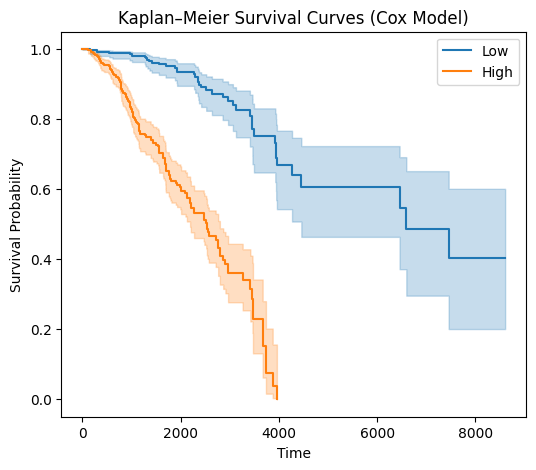

In [47]:
# Plot Kaplan-Meier Curve for Cox Model
from lifelines import KaplanMeierFitter

kmf_cox = KaplanMeierFitter()
km_df = pd.DataFrame({
    "OS": final_df["OS"],
    "OS.time": final_df["OS.time"],
    "RiskGroupCox": final_df["RiskGroupCox"],
    "RiskGroupRSF": final_df["RiskGroupRSF"]
})

plt.figure(figsize=(6, 5))

for label in ["Low", "High"]:
    subset = km_df[km_df["RiskGroupCox"] == label]
    durations = subset["OS.time"]
    events = subset["OS"]

    kmf_cox.fit(durations=durations, event_observed=events, label=label)
    kmf_cox.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival Curves (Cox Model)")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

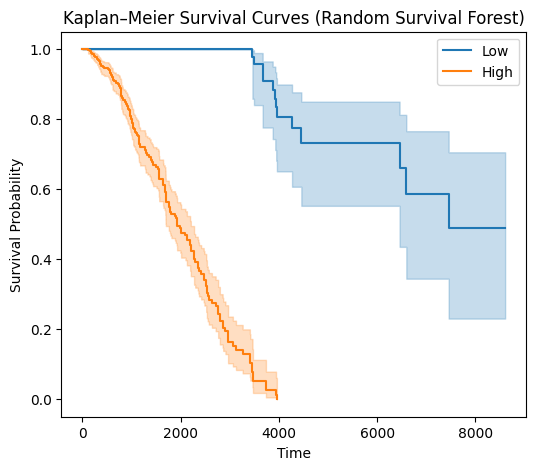

In [48]:
# Plot Kaplan-Meier Curves for RSF
kmf_rsf = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for label in ["Low", "High"]:
    subset = km_df[km_df["RiskGroupRSF"] == label]
    durations = subset["OS.time"]
    events = subset["OS"]

    kmf_rsf.fit(durations=durations, event_observed=events, label=label)
    kmf_rsf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival Curves (Random Survival Forest)")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [49]:
pip install gseapy

In [50]:
import gseapy as gp

# GO analysis
gene_symbols = sorted(list(set(final_genes["gene"])))
go = gp.enrichr(gene_list=gene_symbols, gene_sets=["GO_Biological_Process_2021", "Reactome_2022", "KEGG_2021_Human", "MSigDB_Hallmark_2020"], organism="human", outdir=None)

In [51]:
res = go.results
res.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of cell adhesion (GO:0030155),21/133,0.000002,0.007599,0,0,3.660705,47.509065,CD164;ZFHX3;PLXND1;SEMA4D;TFE3;IL18;CXCR4;GPR4...
1,GO_Biological_Process_2021,glycogen catabolic process (GO:0005980),6/15,0.000049,0.056499,0,0,12.887080,127.880358,RB1CC1;STBD1;PHKG2;PHKB;CALM1;PHKA2
2,GO_Biological_Process_2021,"RNA splicing, via transesterification reaction...",28/251,0.000052,0.056499,0,0,2.454767,24.236572,PRCC;HNRNPU;WDR83;PQBP1;PTBP1;RBM15B;RNF113A;R...
3,GO_Biological_Process_2021,regulation of early endosome to late endosome ...,6/18,0.000160,0.095707,0,0,9.663784,84.464503,RAB21;SNX3;DAB2;RDX;DNAJC13;PTPN23
4,GO_Biological_Process_2021,regulation of cellular component organization ...,18/139,0.000174,0.095707,0,0,2.894009,25.054278,CAMK2D;RAB4B;CISH;SEMA4D;STON1;DAB2IP;HNRNPU;P...


In [52]:
# Select only statistically significant genes / groups
significant = res[res["P-value"] < 0.01]
significant = significant.sort_values("P-value")
significant.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of cell adhesion (GO:0030155),21/133,0.000002,0.007599,0,0,3.660705,47.509065,CD164;ZFHX3;PLXND1;SEMA4D;TFE3;IL18;CXCR4;GPR4...
4535,KEGG_2021_Human,Endocytosis,29/252,0.000021,0.006129,0,0,2.545086,27.370483,ARPC1B;CLTA;CXCR4;SNX3;EEA1;CYTH3;SNX2;PARD6A;...
1,GO_Biological_Process_2021,glycogen catabolic process (GO:0005980),6/15,0.000049,0.056499,0,0,12.887080,127.880358,RB1CC1;STBD1;PHKG2;PHKB;CALM1;PHKA2
4536,KEGG_2021_Human,C-type lectin receptor signaling pathway,16/104,0.000050,0.007178,0,0,3.536018,35.017402,PLK3;PIK3R2;PTPN11;NFKB2;RELB;NFKBIA;PAK1;PIK3...
2,GO_Biological_Process_2021,"RNA splicing, via transesterification reaction...",28/251,0.000052,0.056499,0,0,2.454767,24.236572,PRCC;HNRNPU;WDR83;PQBP1;PTBP1;RBM15B;RNF113A;R...


In [53]:
# Create UBA7 df
uba7_df = survivaldf.copy()
uba7_df.index.name = None

gene_expression_data.index = gene_expression_data["sample"]
sub = gene_expression_data.drop(columns="sample", inplace=True)
sub = gene_expression_data.loc[uba7_df.index]

In [54]:
uba7_df["expr"] = sub["UBA7"]
median_expr = uba7_df["expr"].median()

uba7_df["exprGroup"] = uba7_df["expr"].apply(lambda x: "High" if x >= median_expr else "Low")
uba7_df.head()

,OS,OS.time,expr,exprGroup
TCGA-3C-AAAU-01,0,4047.0,10.0477,High
TCGA-3C-AALI-01,0,4005.0,9.7880,High
TCGA-3C-AALJ-01,0,1474.0,9.9153,High
TCGA-3C-AALK-01,0,1448.0,9.2904,Low
TCGA-4H-AAAK-01,0,348.0,9.9611,High


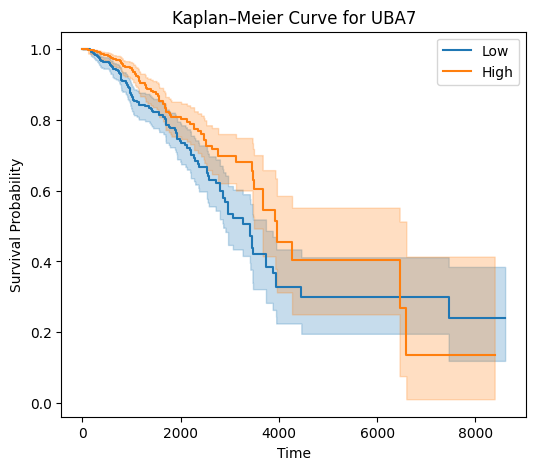

In [55]:
from lifelines import KaplanMeierFitter
kmf_uba7 = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for label in ["Low", "High"]:
    mask = uba7_df["exprGroup"] == label
    kmf_uba7.fit(
        durations=uba7_df.loc[mask, "OS.time"],
        event_observed=uba7_df.loc[mask, "OS"],
        label=label
    )
    kmf_uba7.plot_survival_function(ci_show=True)

plt.title(f"Kaplan–Meier Curve for UBA7")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [56]:
rnf31_df = survivaldf.copy()
rnf31_df.index.name = None
rnf31_df.head()

sub2 = gene_expression_data.loc[rnf31_df.index]
rnf31 = sub2["RNF31"]

rnf31.index = rnf31_df.index
rnf31_df["expr"] = rnf31

rnf31_df.head()

,OS,OS.time,expr
TCGA-3C-AAAU-01,0,4047.0,9.7098
TCGA-3C-AALI-01,0,4005.0,10.1120
TCGA-3C-AALJ-01,0,1474.0,9.7045
TCGA-3C-AALK-01,0,1448.0,10.0422
TCGA-4H-AAAK-01,0,348.0,10.4731


In [57]:
median_expr2 = rnf31_df["expr"].median()

rnf31_df["exprGroup"] = rnf31_df["expr"].apply(lambda x: "High" if x >= median_expr2 else "Low")
rnf31_df.head()

,OS,OS.time,expr,exprGroup
TCGA-3C-AAAU-01,0,4047.0,9.7098,Low
TCGA-3C-AALI-01,0,4005.0,10.1120,High
TCGA-3C-AALJ-01,0,1474.0,9.7045,Low
TCGA-3C-AALK-01,0,1448.0,10.0422,High
TCGA-4H-AAAK-01,0,348.0,10.4731,High


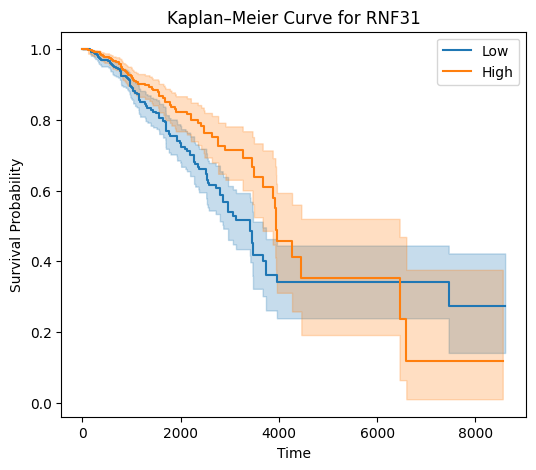

In [58]:
kmf_rnf31 = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for label in ["Low", "High"]:
    mask = rnf31_df["exprGroup"] == label
    kmf_rnf31.fit(
        durations=rnf31_df.loc[mask, "OS.time"],
        event_observed=rnf31_df.loc[mask, "OS"],
        label=label
    )
    kmf_rnf31.plot_survival_function(ci_show=True)

plt.title(f"Kaplan–Meier Curve for RNF31")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

In [59]:
apc_df = survivaldf.copy()
apc_df.index.name = None

sub3 = gene_expression_data.loc[apc_df.index]
apc = sub3["APC"]

apc_df["expr"] = apc
apc_df.head()

,OS,OS.time,expr
TCGA-3C-AAAU-01,0,4047.0,9.9823
TCGA-3C-AALI-01,0,4005.0,8.9912
TCGA-3C-AALJ-01,0,1474.0,8.9647
TCGA-3C-AALK-01,0,1448.0,9.2961
TCGA-4H-AAAK-01,0,348.0,9.4410


In [60]:
expr_med_apc = apc_df["expr"].median()
apc_df["exprGroup"] = apc_df["expr"].apply(lambda x: "High" if x >= expr_med_apc else "Low")

apc_df.head()

,OS,OS.time,expr,exprGroup
TCGA-3C-AAAU-01,0,4047.0,9.9823,High
TCGA-3C-AALI-01,0,4005.0,8.9912,Low
TCGA-3C-AALJ-01,0,1474.0,8.9647,Low
TCGA-3C-AALK-01,0,1448.0,9.2961,Low
TCGA-4H-AAAK-01,0,348.0,9.4410,Low


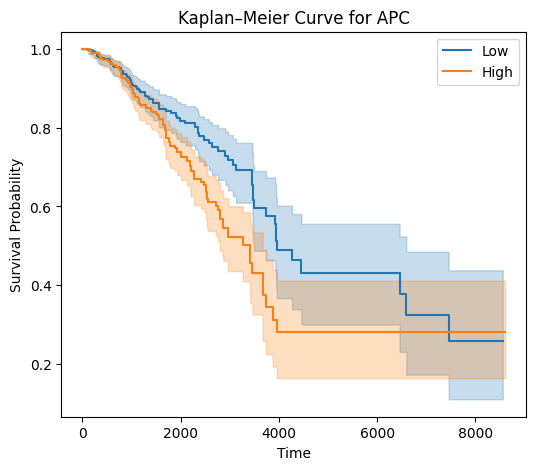

In [61]:
kmf_apc = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for label in ["Low", "High"]:
    mask = apc_df["exprGroup"] == label
    kmf_apc.fit(
        durations=apc_df.loc[mask, "OS.time"],
        event_observed=apc_df.loc[mask, "OS"],
        label=label
    )
    kmf_apc.plot_survival_function(ci_show=True)

plt.title(f"Kaplan–Meier Curve for APC")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()